Customer Segmentation & Retention Analysis

In [ ]:
#Importing required libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')  #keeps output clean

In [122]:
#Data Loading and Exploration
df = pd.read_csv("/Users/laharireddyvari/Desktop/Learnings/DataScienceProject/online_retail.csv")
df.head() #top 5 rows
df.shape #rows*columns
df.info() #about the dataset
df.describe() #basic satistics
df.columns #column names
df.isnull().sum() #counts null values under each column
df.duplicated().sum() #counts duplicate values

#Data Cleaning
(df["CustomerID"].isnull().sum()/len(df))*100 #calculating % of customers id's with null values
df = df.dropna(subset=["CustomerID"]) #dropping the null values
df["CustomerID"] = df["CustomerID"].astype(int) #converting customerid from float to int 
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]) #invoice date to datetime
df.shape
df.isnull().sum()
df.info()
df.head()

#EXPLORATORY DATA ANALYSIS

#To understand the revenue we are creating a new column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["Revenue"].sum()
df["Revenue"].describe()
#Revenue distribution
# plt.figure(figsize=(8,5))
# sns.histplot(df["Revenue"])
# plt.title("Revenue Distribution")
# plt.show()

#The goal is to understand who our customers are.
df["CustomerID"].unique().sum()
#nunique() - Number of unique values
#unique() - Array of unique values
#value_counts - How many rows belong to each country or Frequency
total_customers = df["CustomerID"].nunique()
print(f"Total customers: {total_customers}")
total_orders = df["InvoiceNo"].nunique()
print(f"Total orders: {total_orders}")
df["UnitPrice"].nunique()
total_countries = df["Country"].nunique()
print(f"Total countries: {total_countries}")
df["Country"].value_counts()
total_products = df["Description"].nunique()
print(f"Total unique products: {total_products}") 

#CUSTOMER OVERVIEW
#Grouping per customer by revenue and adding it. So, sum of revenue generated per customer.
customer_revenue = df.groupby("CustomerID")["Revenue"].sum()
order_per_customer = df.groupby("CustomerID")["InvoiceNo"].nunique()
customer_revenue.head()
order_per_customer.head()
one_time_customer = (order_per_customer==1).sum()
print(f"Total no of one time purchase customers: {one_time_customer}")
repeat_customer = (order_per_customer>1).sum()
print(f"Total no of one repeat customers: {repeat_customer}")
repeat_customer_percentage = (repeat_customer)/(total_customers) *100
print(f"Total percentage repeat customers: {repeat_customer_percentage:.2f}%")

#PRODUCT OVERVIEW
products_by_quantity = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)
# print(f"Most popular products: {popular_products}")
products_by_quantity.head(10)
products_by_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)
products_by_revenue.head(10)

#GEOGRAPHY OVERVIEW
customers_by_country = df.groupby("Country")["CustomerID"].nunique().sort_values(ascending=False)
revenue_by_country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
customers_by_country.head(10)
revenue_by_country.head(10)

#What timeperiod dataset covers
df["InvoiceDate"].min()
df["InvoiceDate"].max()
df["Month"] = df["InvoiceDate"].dt.to_period("M")
monthly_Revenue = df.groupby("Month")["Revenue"].sum().sort_index()
monthly_Revenue.head(10)

#RFM Analysis
analysis_date = df["InvoiceDate"].max()+pd.Timedelta(days=1)
analysis_date
recency = df.groupby("CustomerID")["InvoiceDate"].max()
recency = (analysis_date - recency).dt.days
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()
monetary = df.groupby("CustomerID")["Revenue"].sum()
rfm = pd.DataFrame({
    "Recency":recency,
    "Frequency":frequency,
    "Monetary":monetary
})
rfm.head()
rfm.info()
rfm.describe()
negative_customers = (rfm["Monetary"] < 0).sum()
print(negative_customers)
rfm_clean = rfm[rfm["Monetary"] > 0]
rfm_clean = rfm[rfm["Monetary"] > 0].copy()
rfm_clean.shape

#qcut = quantile cut - it divides data into equal-sized groups.
rfm_clean["R_score"] = pd.qcut(
    rfm_clean["Recency"],
    5, #divides customers into 5 groups
    labels=[5,4,3,2,1]
)
rfm_clean["F_score"] = pd.qcut(
    rfm_clean["Frequency"].rank(method="first"),
    #because the frequency of our customers is 1 - 1, the bins cant be same. 
    #So we rank them and then rate.
    5, #divides customers into 5 groups
    labels=[1,2,3,4,5]
)
rfm_clean["M_score"] = pd.qcut(
    rfm_clean["Monetary"],
    5, #divides customers into 5 groups
    labels=[1,2,3,4,5]
)
rfm_clean["RFM_score"] = (
    rfm_clean["R_score"].astype(int).astype(str) +
    rfm_clean["F_score"].astype(int).astype(str) +
    rfm_clean["M_score"].astype(int).astype(str)
)
rfm_clean.head()
def customer_segment (row):
    if row["R_score"]>=4 and row["F_score"]>=4 and row["M_score"]>=4:
        return "Champions"
    elif row["F_score"]>=3 and row["M_score"]>=3:
        return "Loyal Customers"
    elif row["R_score"]>=4 and row["F_score"]<=2:
        return "Potential Loyalists"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    else:
        return "Lost Customers"
    
rfm_clean["Segment"] = rfm_clean.apply(customer_segment, axis=1)
rfm_clean["Segment"].value_counts()

segment_percentage = (
    rfm_clean["Segment"]
    .value_counts(normalize=True)
    * 100
)

segment_percentage

revenue_by_segment = (
    rfm_clean
    .groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)
revenue_by_segment


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64  

Segment
Champions              5582269.250
Loyal Customers        1883430.533
Lost Customers          643523.941
Potential Loyalists     137043.930
At Risk                  67027.300
Name: Monetary, dtype: float64

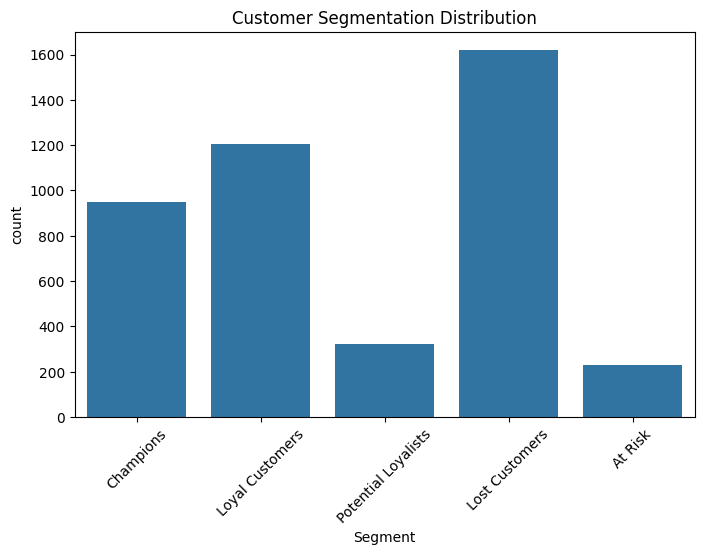

In [123]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=rfm_clean,
    x="Segment"
)
plt.xticks(rotation=45)
plt.title("Customer Segmentation Distribution")
plt.show()

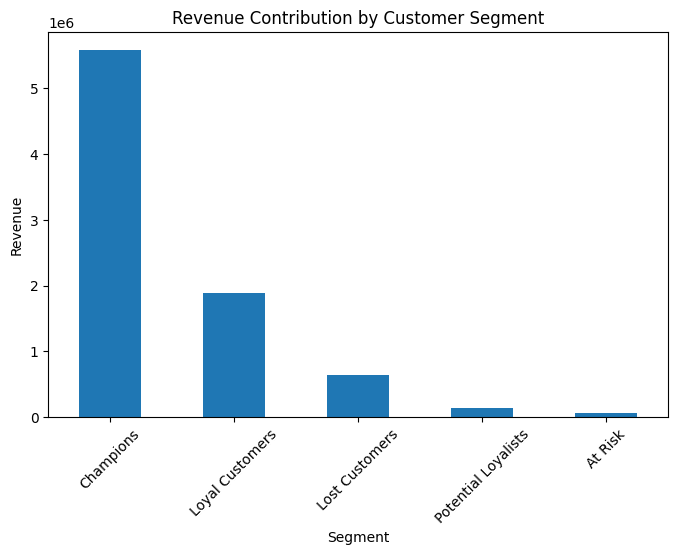

In [124]:
plt.figure(figsize=(8,5))

revenue_by_segment.plot(
    kind="bar"
)
plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [125]:
#A customer who did not purchase for more than 180 days is considered as churned. 
#1 = Churned and 0 = Active
rfm_clean["Churn"] = np.where(
    rfm_clean["Recency"] > 180,
    1,
    0
)
rfm_clean["Churn"].value_counts()
# % of active vs churned customers
churn_percentage = (
    rfm_clean["Churn"]
    .value_counts(normalize=True) * 100
)
print(churn_percentage)

#X contains the independent variables (features) that are used by the model.
#Y is the dependent variable (target) that we want the model to predict.
#Here, the model will learn whether a customer is likely to churn
#based on Recency, Frequency and Monetary value.
X = rfm_clean[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]
y = rfm_clean["Churn"]
print(X.head())
print(y.head())
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Predict churn for the test dataset
y_pred = model.predict(X_test)

print(y_pred[:10])

Churn
0    80.726516
1    19.273484
Name: proportion, dtype: float64
            Recency  Frequency  Monetary
CustomerID                              
12347             2          7   4310.00
12348            75          4   1797.24
12349            19          1   1757.55
12350           310          1    334.40
12352            36         11   1545.41
CustomerID
12347    0
12348    0
12349    0
12350    1
12352    0
Name: Churn, dtype: int64
(3457, 3)
(865, 3)
(3457,)
(865,)
[0 0 1 0 0 0 1 1 0 0]


/Users/laharireddyvari/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/laharireddyvari/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/laharireddyvari/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/laharireddyvari/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/laharireddyvari/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/laharireddyvari/Library/Python/3.9/lib/python/site-packages/skl

In [126]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 100.00%

Confusion Matrix:
[[705   0]
 [  0 160]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       705
           1       1.00      1.00      1.00       160

    accuracy                           1.00       865
   macro avg       1.00      1.00      1.00       865
weighted avg       1.00      1.00      1.00       865



In [132]:
average_order_value = (
    df.groupby("CustomerID")["Revenue"]
      .mean()
)
purchase_frequency = (
    df.groupby("CustomerID")["InvoiceNo"]
      .nunique()
)
estimated_clv = average_order_value * purchase_frequency #Estimated CLV = Total Revenue
rfm_clean["Estimated_CLV"] = rfm_clean["Monetary"]
rfm_clean["CLV_Level"] = pd.qcut(
    rfm_clean["Estimated_CLV"],
    3,
    labels=["Low", "Medium", "High"]
)
rfm_clean[["Estimated_CLV", "CLV_Level"]].head()

,Estimated_CLV,CLV_Level
CustomerID,,
12347,4310.00,High
12348,1797.24,High
12349,1757.55,High
12350,334.40,Low
12352,1545.41,High


In [134]:
summary = rfm_clean.groupby("Segment").agg(
    Customer_Count=("Monetary", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Total_Revenue=("Monetary", "sum")
).round(2)

print(summary)

                     Customer_Count  Avg_Recency  Avg_Frequency  Total_Revenue
Segment                                                                       
At Risk                         227       184.58           2.86       67027.30
Champions                       947        11.62          13.54     5582269.25
Lost Customers                 1619       151.64           1.44      643523.94
Loyal Customers                1206        71.75           4.86     1883430.53
Potential Loyalists             323        17.11           1.37      137043.93
